# Inference Demo

Running the full pipeline on unseen test images to show what the user sees:
quality score, detected issues with feature evidence, and the CNN attention heatmap.

This is essentially what the FastAPI backend does on each upload,
but here we can visualize each step.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from config import DATA_DIR, MODELS_DIR
from ml.inference import QualityAnalyzer

DATA_GEN = DATA_DIR / "generated"
analyzer = QualityAnalyzer(MODELS_DIR)
print(f"Model: {analyzer.model_type}")
print(f"Classifiers: {list(analyzer.classifiers.keys())}")

Model: MobileNetV2
Classifiers: ['blur', 'underexposure', 'overexposure', 'noise', 'low_contrast', 'corruption']


## Pick diverse test samples

In [2]:
test_meta = pd.read_csv(DATA_GEN / "test" / "metadata.csv")
img_dir = DATA_GEN / "test" / "images"

# one of each type
sample_rows = []
for dt in ["GOOD", "BLUR", "NOISE", "UNDEREXPOSURE", "OVEREXPOSURE", 
           "LOW_CONTRAST", "JPEG_CORRUPTION", "SEVERE_DEGRADATION"]:
    sub = test_meta[test_meta['degradation_type'] == dt]
    if len(sub):
        sample_rows.append(sub.iloc[len(sub)//2])
print(f"Testing {len(sample_rows)} images")

Testing 8 images


## Run analysis on each

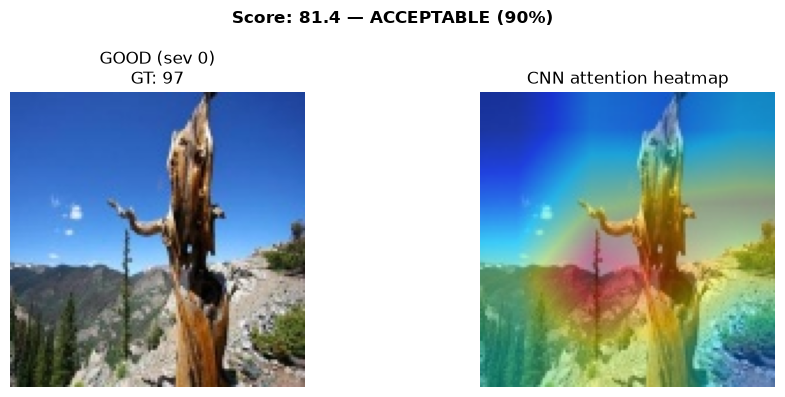

  underexposure: medium (61%) â€” high_freq_energy=0.69, michelson_contrast=1.0, colorfulness=89.419



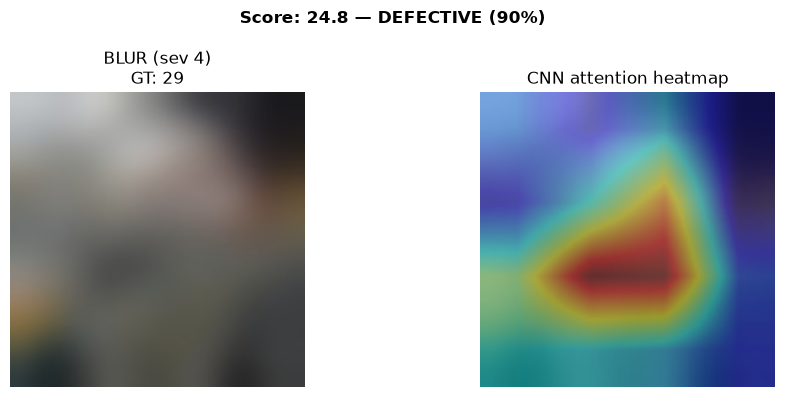

  blur: high (90%) â€” local_variance_mean=6.437, high_freq_energy=0.403, texture_energy=0.058



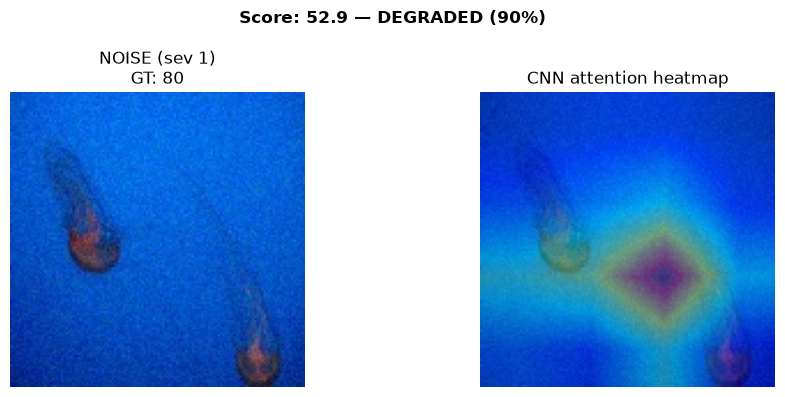

  underexposure: high (86%) â€” high_freq_energy=0.774, mean_saturation=241.683, edge_density=0.009
  low_contrast: high (99%) â€” high_freq_energy=0.774, frac_overexposed=0.0, brightness_std=14.444



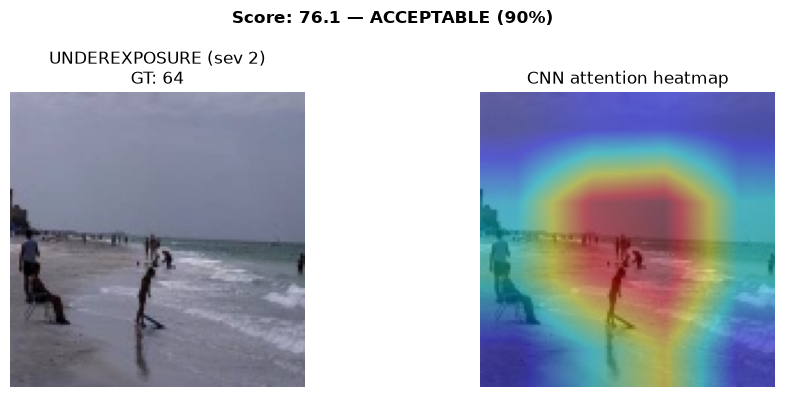

  overexposure: medium (50%) â€” laplacian_variance=674.429, local_variance_mean=158.33, brightness_std=26.954
  corruption: medium (63%) â€” edge_density=0.054, rms_contrast=0.215, local_variance_mean=158.33



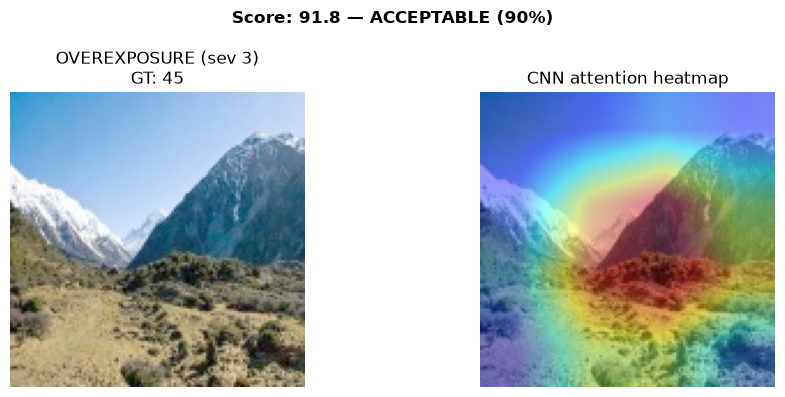

  overexposure: high (83%) â€” mean_brightness=141.785, laplacian_variance=2887.133, high_freq_energy=0.677
  noise: medium (51%) â€” high_freq_energy=0.677, entropy=7.647, mean_brightness=141.785



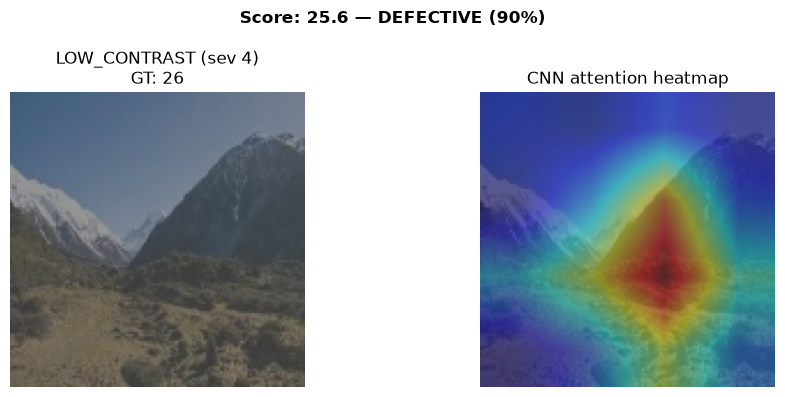

  low_contrast: high (100%) â€” michelson_contrast=0.471, frac_overexposed=0.0, local_variance_mean=57.767



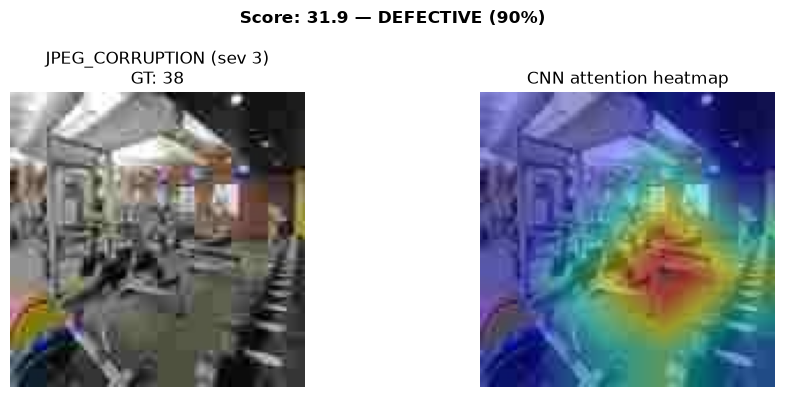

  corruption: high (83%) â€” entropy=7.544, edge_density=0.204, dynamic_range=240.0



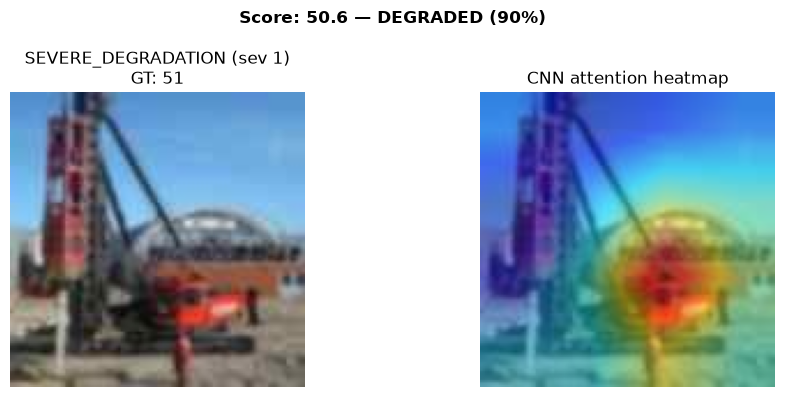

  blur: high (89%) â€” high_freq_energy=0.434, local_variance_mean=280.205, noise_sigma_estimate=0.703
  corruption: medium (65%) â€” high_freq_energy=0.434, local_variance_mean=280.205, entropy=7.304



In [3]:
results = []
for row in sample_rows:
    img_bytes = open(str(img_dir / row['filename']), 'rb').read()
    r = analyzer.analyze(img_bytes)
    results.append(r)
    
    # display
    img = cv2.cvtColor(cv2.imread(str(img_dir / row['filename'])), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].imshow(img)
    axes[0].set_title(f"{row['degradation_type']} (sev {row['severity']})\nGT: {row['quality_score']:.0f}")
    axes[0].axis('off')
    
    if r['heatmap']:
        hm = cv2.imdecode(np.frombuffer(base64.b64decode(r['heatmap'].split(',')[1]), np.uint8), cv2.IMREAD_COLOR)
        axes[1].imshow(cv2.cvtColor(hm, cv2.COLOR_BGR2RGB))
        axes[1].set_title("CNN attention heatmap")
    axes[1].axis('off')
    
    plt.suptitle(f"Score: {r['quality_score']:.1f} â€” {r['quality_label']} ({r['confidence']:.0%})", fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # print issues
    if r['issues']:
        for iss in r['issues']:
            evidence = ', '.join(f"{e['feature']}={e['value']}" for e in iss.get('evidence', []))
            print(f"  {iss['type']}: {iss['severity']} ({iss['confidence']:.0%}) â€” {evidence}")
    else:
        print("  No issues detected")
    print()

## Summary table

In [4]:
summary = []
for row, r in zip(sample_rows, results):
    summary.append({
        "Type": row['degradation_type'],
        "Severity": row['severity'],
        "GT Score": row['quality_score'],
        "Predicted": r['quality_score'],
        "Label": r['quality_label'],
        "Issues": len(r['issues']),
        "Conf": f"{r['confidence']:.0%}",
    })
print(pd.DataFrame(summary).to_string(index=False))

              Type  Severity  GT Score  Predicted      Label  Issues Conf
              GOOD         0      96.9       81.4 ACCEPTABLE       1  90%
              BLUR         4      29.1       24.8  DEFECTIVE       1  90%
             NOISE         1      79.7       52.9   DEGRADED       2  90%
     UNDEREXPOSURE         2      63.6       76.1 ACCEPTABLE       2  90%
      OVEREXPOSURE         3      45.1       91.8 ACCEPTABLE       2  90%
      LOW_CONTRAST         4      26.1       25.6  DEFECTIVE       1  90%
   JPEG_CORRUPTION         3      38.0       31.9  DEFECTIVE       1  90%
SEVERE_DEGRADATION         1      50.9       50.6   DEGRADED       2  90%


## How explainability works

Every prediction comes with two levels of explanation:

1. **Feature evidence** — for each detected issue, we show the top 3 features
   that drove the logistic regression decision. Since LR coefficients are linear,
   we can compute exactly how much each feature contributed. e.g. blur gets
   detected because laplacian_variance=12 (very low = no edges = blurry)

2. **Grad-CAM heatmap** — we take the last convolutional layer of the CNN,
   average the channel activations, and upsample to the input size. This shows
   which spatial regions the CNN relied on most. Red = high attention = this
   area influenced the score

Together these let a user understand *why* an image got a certain score
and *where* the problems are located.


In [5]:
print("To run the full server: uvicorn backend.app:app --reload")

To run the full server: uvicorn backend.app:app --reload
